In [1]:
#Pawel Maczuga and Maciej Paszynski (2023)
#If you use this code, please cite https://link.springer.com/chapter/10.1007/978-3-031-97629-2_13
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from torch import nn
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from functools import partial
import time
from typing import Tuple

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

SEED = 0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [2]:
LENGTH = 1.                     # Domain size in x axis. Always starts at 0
TOTAL_TIME = 1.                 # Domain size in t axis. Always starts at 0
N_POINTS = 30                   # Number of in single asxis
N_POINTS_PLOT = 150             # Number of points in single axis used in plotting
WEIGHT_RESIDUAL = 1.0           # Weight of residual part of loss function
WEIGHT_INITIAL = 3.0            # Weight of initial part of loss function
WEIGHT_BOUNDARY = 1.0           # Weight of boundary part of loss function
LAYERS = 4
NEURONS_PER_LAYER = 160
EPOCHS = 50_000
LEARNING_RATE = 0.001

In [3]:
def initial_condition(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
  #  ---.  c3
  #      \
  #       \____
  #  0  c1 c2
    r = torch.sqrt((x-0.5)**2 + (y-0.5)**2)
    c1 = 0.01
    c2 = 0.4
    c3 = 1.0
    h = (r - c1) / (c2-c1)
    res = c3 * (h-1) * (h-1) * (h+1) * (h+1) * (h < 1)
    return res


def fuel_initial_condition(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """A map of the fuel S(x, y, t=0)."""
    return 0.5 * (1.0 - torch.tanh(20 * (x - 0.5)))

In [4]:
# Model coefficients — shared by the PINN residual and the FDM reference solver.
C1, C2 = 1.0, 1.0
C3, C4 = 0.1, 0.01
C5, C6 = 0.1, 0.001
CR, CF = 3.0, 4.0
U_IGN = 0.4
K_IGN = 15.0
T0 = 0.0
bx, by = 0.0, 0.5

In [5]:
class PINN(nn.Module):
    """Simple neural network accepting three features as input (x, y, t) and returning
    two outputs: the temperature u and the fuel S

    In the context of PINNs, the neural network is used as universal function approximator
    to approximate the solution of the differential equation
    """
    def __init__(self, num_hidden: int, dim_hidden: int, act=nn.Tanh()):

        super().__init__()

        self.layer_in = nn.Linear(3, dim_hidden)
        self.layer_out = nn.Linear(dim_hidden, 2)

        num_middle = num_hidden - 1
        self.middle_layers = nn.ModuleList(
            [nn.Linear(dim_hidden, dim_hidden) for _ in range(num_middle)]
        )
        self.act = act

    def forward(self, x, y, t):

        x_stack = torch.cat([x, y, t], dim=1)
        out = self.act(self.layer_in(x_stack))
        for layer in self.middle_layers:
            out = self.act(layer(out))
        logits = self.layer_out(out)

        return logits

    def device(self):
        return next(self.parameters()).device


def f(pinn: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor, output_value: int = 0) -> torch.Tensor:
    """Compute the value of the approximate solution from the NN model

    output_value = 0 -> temperatura u, output_value = 1 -> paliwo S
    """
    return pinn(x, y, t)[:, output_value:output_value+1]


def df(output: torch.Tensor, input: torch.Tensor, order: int = 1) -> torch.Tensor:
    """Compute neural network derivative with respect to input features using PyTorch autograd engine"""
    df_value = output
    for _ in range(order):
        df_value = torch.autograd.grad(
            df_value,
            input,
            grad_outputs=torch.ones_like(input),
            create_graph=True,
            retain_graph=True,
        )[0]

    return df_value

def dfdt(pinn: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor, order: int = 1, output_value: int = 0):
    f_value = f(pinn, x, y, t, output_value)
    return df(f_value, t, order=order)


def dfdx(pinn: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor, order: int = 1, output_value: int = 0):
    f_value = f(pinn, x, y, t, output_value)
    return df(f_value, x, order=order)

def dfdy(pinn: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor, order: int = 1, output_value: int = 0):
    f_value = f(pinn, x, y, t, output_value)
    return df(f_value, y, order=order)


In [6]:
def get_boundary_points(x_domain, y_domain, t_domain, n_points, device = torch.device("cpu"), requires_grad=True):
    """
         .+------+
       .' |    .'|
      +---+--+'  |
      |   |  |   |
    y |  ,+--+---+
      |.'    | .' t
      +------+'
         x
    """
    x_linspace = torch.linspace(x_domain[0], x_domain[1], n_points)
    y_linspace = torch.linspace(y_domain[0], y_domain[1], n_points)
    t_linspace = torch.linspace(t_domain[0], t_domain[1], n_points)

    x_grid, t_grid = torch.meshgrid( x_linspace, t_linspace, indexing="ij")
    y_grid, _      = torch.meshgrid( y_linspace, t_linspace, indexing="ij")

    x_grid = x_grid.reshape(-1, 1).to(device)
    x_grid.requires_grad = requires_grad
    y_grid = y_grid.reshape(-1, 1).to(device)
    y_grid.requires_grad = requires_grad
    t_grid = t_grid.reshape(-1, 1).to(device)
    t_grid.requires_grad = requires_grad

    x0 = torch.full_like(t_grid, x_domain[0], requires_grad=requires_grad)
    x1 = torch.full_like(t_grid, x_domain[1], requires_grad=requires_grad)
    y0 = torch.full_like(t_grid, y_domain[0], requires_grad=requires_grad)
    y1 = torch.full_like(t_grid, y_domain[1], requires_grad=requires_grad)

    down    = (x_grid, y0,     t_grid)
    up      = (x_grid, y1,     t_grid)
    left    = (x0,     y_grid, t_grid)
    right   = (x1,     y_grid, t_grid)

    return down, up, left, right

In [7]:
def get_initial_points(x_domain, y_domain, t_domain, n_points, device = torch.device("cpu"), requires_grad=True):
    x_linspace = torch.linspace(x_domain[0], x_domain[1], n_points)
    y_linspace = torch.linspace(y_domain[0], y_domain[1], n_points)
    x_grid, y_grid = torch.meshgrid( x_linspace, y_linspace, indexing="ij")
    x_grid = x_grid.reshape(-1, 1).to(device)
    x_grid.requires_grad = requires_grad
    y_grid = y_grid.reshape(-1, 1).to(device)
    y_grid.requires_grad = requires_grad
    t0 = torch.full_like(x_grid, t_domain[0], requires_grad=requires_grad)
    return (x_grid, y_grid, t0)

In [8]:
def get_interior_points(x_domain, y_domain, t_domain, n_points, device = torch.device("cpu"), requires_grad=True):  # Not used
    x_raw = torch.linspace(x_domain[0], x_domain[1], steps=n_points, requires_grad=requires_grad)
    y_raw = torch.linspace(y_domain[0], y_domain[1], steps=n_points, requires_grad=requires_grad)
    t_raw = torch.linspace(t_domain[0], t_domain[1], steps=n_points, requires_grad=requires_grad)
    grids = torch.meshgrid(x_raw, y_raw, t_raw, indexing="ij")

    x = grids[0].reshape(-1, 1).to(device)
    y = grids[1].reshape(-1, 1).to(device)
    t = grids[2].reshape(-1, 1).to(device)

    return x, y, t

In [9]:
def get_random_interior_points(x_domain, y_domain, t_domain, n_points, device=torch.device("cpu"), requires_grad=True):
    n = n_points ** 3
    x = ((x_domain[1]-x_domain[0]) * torch.rand(n,1) + x_domain[0]).to(device).requires_grad_(requires_grad)
    y = ((y_domain[1]-y_domain[0]) * torch.rand(n,1) + y_domain[0]).to(device).requires_grad_(requires_grad)
    t = ((t_domain[1]-t_domain[0]) * torch.rand(n,1) + t_domain[0]).to(device).requires_grad_(requires_grad)
    return x, y, t

In [10]:
class Loss:
    def __init__(
        self,
        x_domain: Tuple[float, float],
        y_domain: Tuple[float, float],
        t_domain: Tuple[float, float],
        n_points: int,
        initial_condition: Callable,
        fuel_initial_condition: Callable,
        weight_r: float = 1.0,
        weight_b: float = 1.0,
        weight_i: float = 1.0,
        verbose: bool = False,
    ):
        self.x_domain = x_domain
        self.y_domain = y_domain
        self.t_domain = t_domain
        self.n_points = n_points
        self.initial_condition = initial_condition
        self.fuel_initial_condition = fuel_initial_condition
        self.weight_r = weight_r
        self.weight_b = weight_b
        self.weight_i = weight_i

    def residual_loss(self, pinn: PINN):
        x, y, t = get_random_interior_points(self.x_domain, self.y_domain, self.t_domain, self.n_points, pinn.device())
        s = f(pinn, x, y, t, output_value=1)
        r = torch.sigmoid(K_IGN * (f(pinn, x, y, t) - U_IGN))
        loss1_2 = C1 * dfdt(pinn, x, y, t) + C2 * bx * dfdx(pinn, x, y, t, order=1) + C2 * by * dfdy(pinn, x, y, t, order=1)
        loss3  = - C3 * dfdx(pinn, x, y, t, order=2) - C3 * dfdy(pinn, x, y, t, order=2)
        loss4a = - C4 * 3.0 * f(pinn, x, y, t)**2 * dfdx(pinn, x, y, t, order=1)**2 - C4 * 3.0 * f(pinn, x, y, t)**2 * dfdy(pinn, x, y, t, order=1)**2
        loss4b =  - C4 * f(pinn, x, y, t)**3 * dfdx(pinn, x, y, t, order=2) - C4 * f(pinn, x, y, t)**3 * dfdy(pinn, x, y, t, order=2)
        loss5_6 = - C5 * (T0 - f(pinn, x, y, t)) - C6 * (T0**4 - f(pinn, x, y, t)**4)
        loss7 = - CR * s * r
        loss =  loss1_2 + loss3 + loss4a + loss4b + loss5_6 + loss7
        loss_fuel = dfdt(pinn, x, y, t, output_value=1) + CF * s * r
        return loss.pow(2).mean() + loss_fuel.pow(2).mean()

    def initial_loss(self, pinn: PINN):
        x, y, t = get_initial_points(self.x_domain, self.y_domain, self.t_domain, self.n_points, pinn.device())
        pinn_init = self.initial_condition(x, y)
        loss = f(pinn, x, y, t) - pinn_init
        fuel_init = self.fuel_initial_condition(x, y)
        loss_fuel = f(pinn, x, y, t, output_value=1) - fuel_init
        return loss.pow(2).mean() + loss_fuel.pow(2).mean()

    def boundary_loss(self, pinn: PINN):
        down, up, left, right = get_boundary_points(self.x_domain, self.y_domain, self.t_domain, self.n_points, pinn.device())
        x_down,  y_down,  t_down    = down
        x_up,    y_up,    t_up      = up
        x_left,  y_left,  t_left    = left
        x_right, y_right, t_right   = right

        loss_down  = dfdy( pinn, x_down,  y_down,  t_down  )
        loss_up    = dfdy( pinn, x_up,    y_up,    t_up    )
        loss_left  = dfdx( pinn, x_left,  y_left,  t_left  )
        loss_right = dfdx( pinn, x_right, y_right, t_right )

        return loss_down.pow(2).mean()  + \
            loss_up.pow(2).mean()    + \
            loss_left.pow(2).mean()  + \
            loss_right.pow(2).mean()

    def verbose(self, pinn: PINN):
        """
        Returns all parts of the loss function

        Not used during training! Only for checking the results later.
        """
        residual_loss = self.residual_loss(pinn)
        initial_loss = self.initial_loss(pinn)
        boundary_loss = self.boundary_loss(pinn)

        final_loss = \
            self.weight_r * residual_loss + \
            self.weight_i * initial_loss + \
            self.weight_b * boundary_loss

        return final_loss, residual_loss, initial_loss, boundary_loss

    def __call__(self, pinn: PINN):
        return self.verbose(pinn)[0]

In [11]:
def train_model(
    nn_approximator: PINN,
    loss_fn: Callable,
    learning_rate: int = 0.01,
    max_epochs: int = 1_000
) -> PINN:

    optimizer = torch.optim.Adam(nn_approximator.parameters(), lr=learning_rate)
    loss_values = []
    loss_residual = []
    loss_initial = []
    loss_boundary = []
    for epoch in range(max_epochs):

        try:
            total, residual, initial, boundary = loss_fn.verbose(nn_approximator)
            loss: torch.Tensor = total
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_values.append(loss.item())
            loss_residual.append(residual.item())
            loss_initial.append(initial.item())
            loss_boundary.append(boundary.item())
            if (epoch + 1) % 1000 == 0:
                print(f"Epoch: {epoch + 1} - Loss: {float(loss):>7f}")

        except KeyboardInterrupt:
            break

    return nn_approximator, np.array(loss_values), np.array(loss_residual), \
           np.array(loss_initial), np.array(loss_boundary)

In [12]:
def plot_solution(pinn: PINN, x: torch.Tensor, t: torch.Tensor, figsize=(8, 6), dpi=100):

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    x_raw = torch.unique(x).reshape(-1, 1)
    t_raw = torch.unique(t)

    def animate(i):

        if not i % 10 == 0:
            t_partial = torch.ones_like(x_raw) * t_raw[i]
            f_final = f(pinn, x_raw, t_partial)
            ax.clear()
            ax.plot(
                x_raw.detach().numpy(), f_final.detach().numpy(), label=f"Time {float(t[i])}"
            )
            ax.set_ylim(-1, 1)
            ax.legend()

    n_frames = t_raw.shape[0]
    return FuncAnimation(fig, animate, frames=n_frames, interval=100, repeat=False)

def plot_color(z: torch.Tensor, x: torch.Tensor, y: torch.Tensor, n_points_x, n_points_t, title, figsize=(8, 6), dpi=100, cmap="viridis"):
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    z_raw = z.detach().cpu().numpy()
    x_raw = x.detach().cpu().numpy()
    y_raw = y.detach().cpu().numpy()
    X = x_raw.reshape(n_points_x, n_points_t)
    Y = y_raw.reshape(n_points_x, n_points_t)
    Z = z_raw.reshape(n_points_x, n_points_t)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    c = ax.pcolormesh(X, Y, Z, cmap=cmap)
    fig.colorbar(c, ax=ax)

    return fig

def plot_3D(z: torch.Tensor, x: torch.Tensor, y: torch.Tensor, n_points_x, n_points_t, title, figsize=(8, 6), dpi=100, limit=0.2):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(projection='3d')
    z_raw = z.detach().cpu().numpy()
    x_raw = x.detach().cpu().numpy()
    y_raw = y.detach().cpu().numpy()
    X = x_raw.reshape(n_points_x, n_points_t)
    Y = y_raw.reshape(n_points_x, n_points_t)
    Z = z_raw.reshape(n_points_x, n_points_t)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axes.set_zlim3d(bottom=-limit, top=limit)

    c = ax.plot_surface(X, Y, Z)

    return fig

def running_average(y, window=100):
    cumsum = np.cumsum(np.insert(y, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / float(window)

In [13]:
# # Initialization of the training process. Skip this cell when loading a pre-trained model.

# pinn = PINN(LAYERS, NEURONS_PER_LAYER, act=nn.Tanh()).to(device)   
# x_domain = [0.0, LENGTH]
# y_domain = [0.0, LENGTH]
# t_domain = [0.0, TOTAL_TIME]

# loss_fn = Loss(
#     x_domain,
#     y_domain,
#     t_domain,
#     N_POINTS,
#     initial_condition,
#     fuel_initial_condition,
#     WEIGHT_RESIDUAL,
#     WEIGHT_BOUNDARY,
#     WEIGHT_INITIAL
# )

# if torch.cuda.is_available(): torch.cuda.synchronize()
# t0 = time.perf_counter()

# pinn_trained, *losses = train_model(
#     pinn, loss_fn=loss_fn, learning_rate=LEARNING_RATE, max_epochs=EPOCHS)

# if torch.cuda.is_available(): torch.cuda.synchronize()
# t_train = time.perf_counter() - t0
# print(f"Training time: {t_train:.1f} s = {t_train/60:.1f} min   ({t_train/EPOCHS*1000:.2f} ms/epoch)")
# loss_values, loss_residual, loss_initial, loss_boundary = losses

In [14]:
# Reading the parameters and loss history from previously saved files. Skip this cell when training the model from scratch.

pinn = PINN(LAYERS, NEURONS_PER_LAYER, act=nn.Tanh()).to(device)

checkpoint_path = "pinn_wildfire_half_wind.pt"
pinn.load_state_dict(torch.load(checkpoint_path, map_location=device))

pinn.eval()

x_domain = [0.0, LENGTH]
y_domain = [0.0, LENGTH]
t_domain = [0.0, TOTAL_TIME]

loss_fn = Loss(
    x_domain,
    y_domain,
    t_domain,
    N_POINTS,
    initial_condition,
    fuel_initial_condition,
    WEIGHT_RESIDUAL,
    WEIGHT_BOUNDARY,
    WEIGHT_INITIAL
)

losses_data = np.load("pinn_wildfire_half_wind_losses.npz")
loss_values = losses_data["loss_values"]
loss_residual = losses_data["loss_residual"]
loss_initial = losses_data["loss_initial"]
loss_boundary = losses_data["loss_boundary"]


In [15]:
pinn = pinn.cpu()
pinn_trained=pinn

In [ ]:
# # Save the trained model and loss history. Can be skipped when loading a pre-trained model.
# torch.save(pinn_trained.state_dict(), "pinn_wildfire_half_wind.pt")

# np.savez("pinn_wildfire_half_wind_losses.npz",
#          loss_values=loss_values, loss_residual=loss_residual,
#          loss_initial=loss_initial, loss_boundary=loss_boundary)

In [17]:
pinn = pinn.cpu()
pinn_trained=pinn

In [18]:
torch.manual_seed(SEED)  
losses = loss_fn.verbose(pinn)
print(f'Total loss: \t{losses[0]:.5f}    ({losses[0]:.3E})')
print(f'Interior loss: \t{losses[1]:.5f}    ({losses[1]:.3E})')
print(f'Initial loss: \t{losses[2]:.5f}    ({losses[2]:.3E})')
print(f'Boundary loss: \t{losses[3]:.5f}    ({losses[3]:.3E})')

Total loss: 	0.00011    (1.061E-04)
Interior loss: 	0.00005    (4.712E-05)
Initial loss: 	0.00001    (9.713E-06)
Boundary loss: 	0.00003    (2.979E-05)


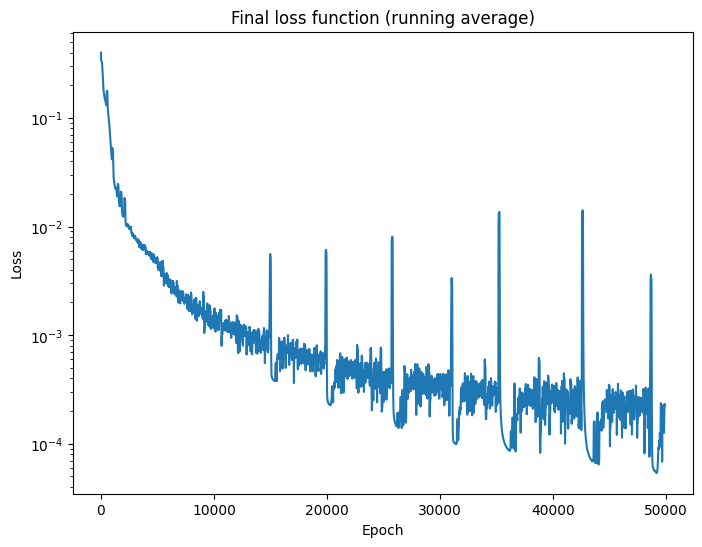

In [19]:
# Final loss function
average_loss = running_average(loss_values, window=100)
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Final loss function (running average)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.plot(average_loss)
ax.set_yscale('log')

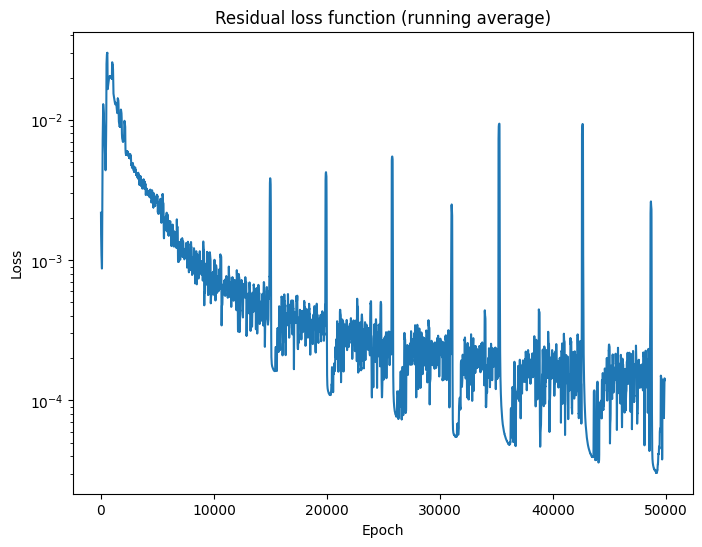

In [20]:
# Residual loss function
average_loss = running_average(loss_residual, window=100)
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Residual loss function (running average)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.plot(average_loss)
ax.set_yscale('log')

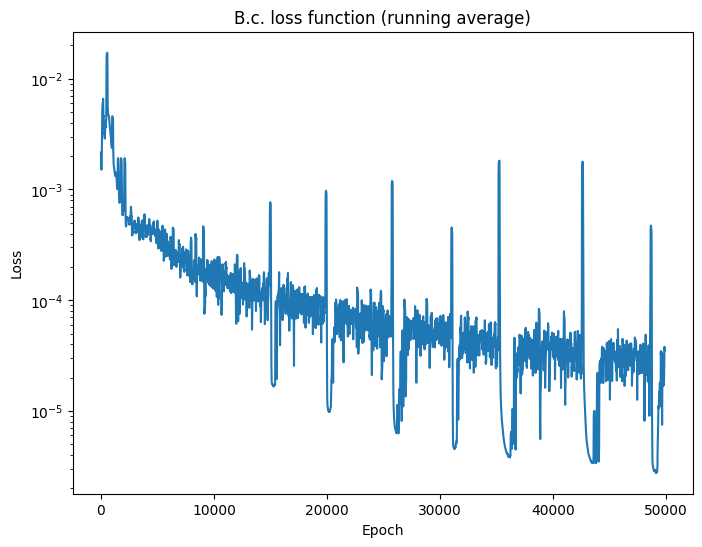

In [21]:
# B. c. loss function
average_loss = running_average(loss_boundary, window=100)
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("B.c. loss function (running average)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.plot(average_loss)
ax.set_yscale('log')

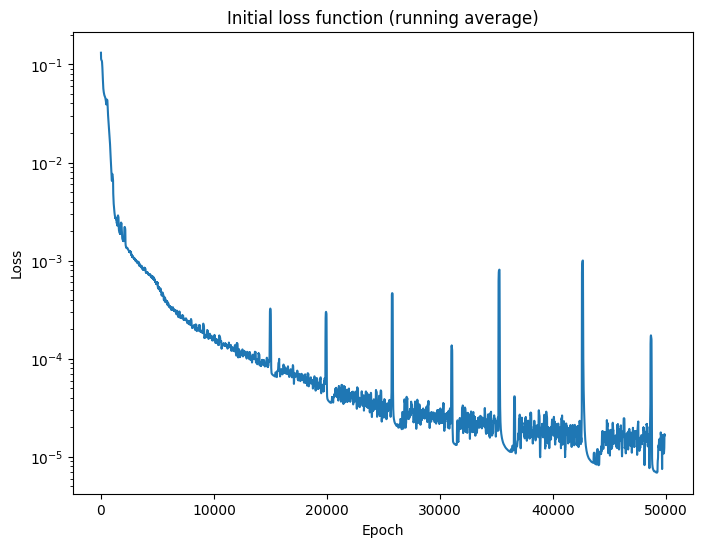

In [22]:
# Initial loss function
average_loss = running_average(loss_initial, window=100)
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Initial loss function (running average)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.plot(average_loss)
ax.set_yscale('log')

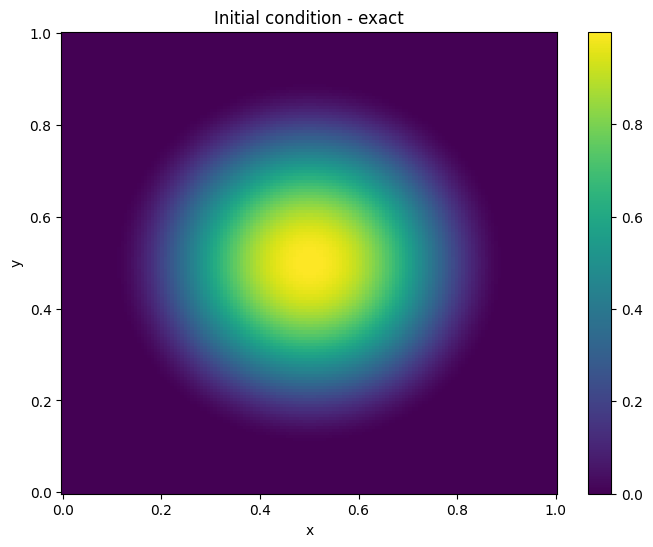

In [23]:
x, y, _ = get_initial_points(x_domain, y_domain, t_domain, N_POINTS_PLOT, requires_grad=False)
z = initial_condition(x, y)
fig = plot_color(z, x, y, N_POINTS_PLOT, N_POINTS_PLOT, "Initial condition - exact")

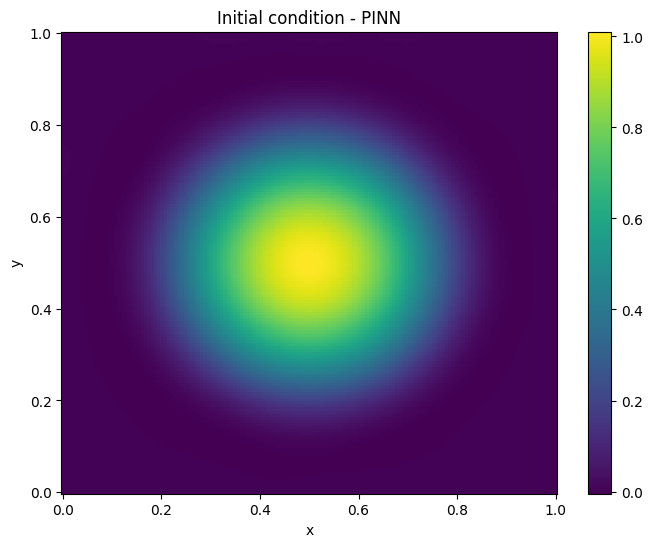

In [24]:
t_value = 0.0
t = torch.full_like(x, t_value)
z = f(pinn, x, y, t)
fig = plot_color(z, x, y, N_POINTS_PLOT, N_POINTS_PLOT, "Initial condition - PINN")

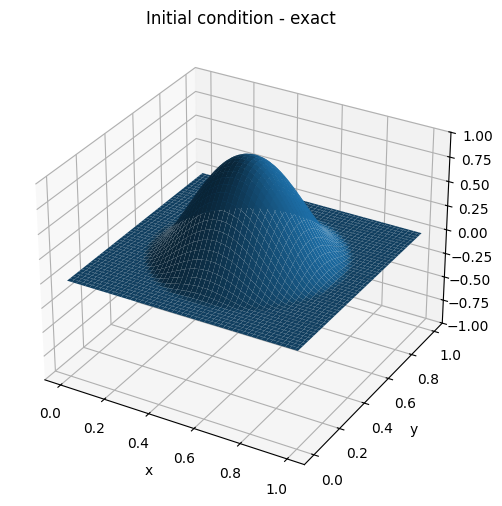

In [25]:
x, y, _ = get_initial_points(x_domain, y_domain, t_domain, N_POINTS_PLOT, requires_grad=False)
z = initial_condition(x, y)
fig = plot_3D(z, x, y, N_POINTS_PLOT, N_POINTS_PLOT, "Initial condition - exact", limit=1.0)

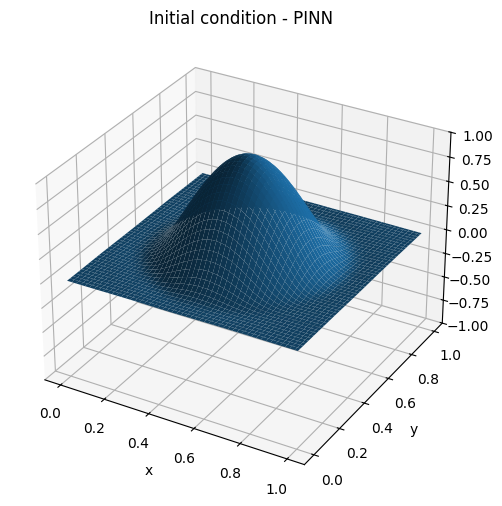

In [26]:
t_value = 0.0
t = torch.full_like(x, t_value)
z = f(pinn, x, y, t)
fig = plot_3D(z, x, y, N_POINTS_PLOT, N_POINTS_PLOT, "Initial condition - PINN", limit=1.0)

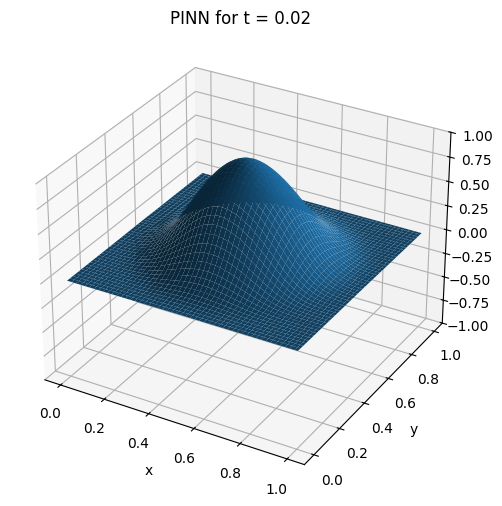

In [27]:
# Set t_value to see the PINN's outcome at that time - 3D
t_value = 0.02
t = torch.full_like(x, t_value)
z = f(pinn, x, y, t)
fig = plot_3D(z, x, y, N_POINTS_PLOT, N_POINTS_PLOT, f"PINN for t = {t_value}",  limit=1.0)

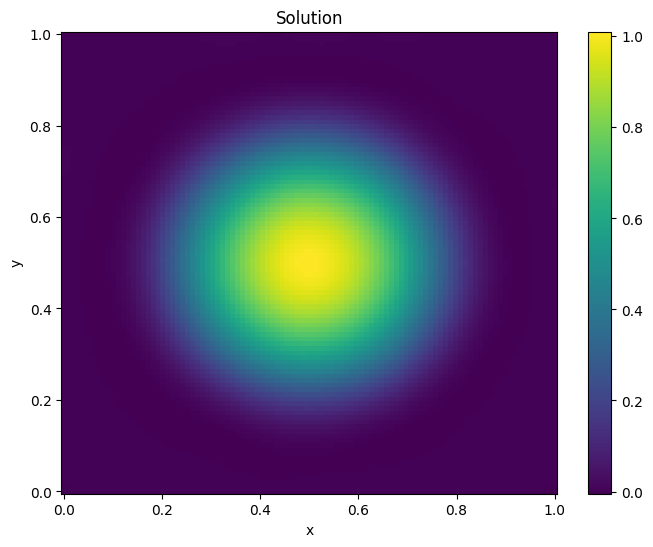

In [28]:
# Set t_value to see the PINN's outcome at that time - 2D
t_value=0.00
x_raw = torch.linspace(x_domain[0], x_domain[1], steps=100, requires_grad=True)
y_raw = torch.linspace(y_domain[0], y_domain[1], steps=100, requires_grad=True)
t_raw = torch.linspace(t_domain[0], t_domain[1], steps=100, requires_grad=True)
grids = torch.meshgrid(x_raw, y_raw, indexing="ij")
x = grids[0].flatten().reshape(-1, 1).to(device)
y = grids[1].flatten().reshape(-1, 1).to(device)
t_tensor = torch.Tensor([t_value]*10000).reshape(-1, 1).to(device)
z = f(pinn.to(device), x, y, t_tensor)
color = plot_color(z.cpu(), x.cpu(), y.cpu(), 100, 100, "Solution")

In [29]:
from IPython.display import HTML

device = next(pinn_trained.parameters()).device
N = 80
n_frames = 60

x_raw = torch.linspace(0, 1, N)
y_raw = torch.linspace(0, 1, N)
XX, YY = np.meshgrid(x_raw.numpy(), y_raw.numpy())
xf = torch.tensor(XX.reshape(-1, 1), dtype=torch.float32).to(device)
yf = torch.tensor(YY.reshape(-1, 1), dtype=torch.float32).to(device)

times = np.linspace(0, 1, n_frames)
frames = []
fuel_frames_pinn = []
pinn_trained.eval()
for tv in times:
    t_flat = torch.full_like(xf, tv)
    with torch.no_grad():
        out = pinn_trained(xf, yf, t_flat).cpu()
    frames.append(out[:, 0:1].reshape(N, N).numpy())
    fuel_frames_pinn.append(out[:, 1:2].reshape(N, N).numpy())

vmin = min(f.min() for f in frames)
vmax = max(f.max() for f in frames)

fig, ax = plt.subplots(figsize=(5, 4.5))

def update(i):
    ax.cla()
    ax.contourf(XX, YY, frames[i], levels=40, cmap="inferno")  # bez vmin/vmax
    ax.set_title(f"t = {times[i]:.2f}  max={frames[i].max():.4f}")

anim = FuncAnimation(fig, update, frames=n_frames, interval=100)
plt.close(fig)
HTML(anim.to_jshtml())

In [30]:
fig, ax = plt.subplots(figsize=(5, 4.5))

def update_fuel(i):
    ax.cla()
    ax.contourf(XX, YY, fuel_frames_pinn[i], levels=40, cmap="YlGn", vmin=0, vmax=1)
    ax.set_title(f"Fuel  t = {times[i]:.2f}  min={fuel_frames_pinn[i].min():.3f}")

anim_fuel = FuncAnimation(fig, update_fuel, frames=n_frames, interval=100)
plt.close(fig)
HTML(anim_fuel.to_jshtml())

FDM time: 20.7 s
Prediction time: 14.8 ms for 256000 points
RMSE (temperature): min=2.86e-04  max=2.77e-03  avg=6.74e-04
RMSE (fuel): min=1.18e-03  max=1.54e-03  avg=1.38e-03
Relative L2 error (temperature): min=0.0011  max=0.0086  avg=0.0024
Relative L2 error (fuel): min=0.0020  max=0.0036  avg=0.0027


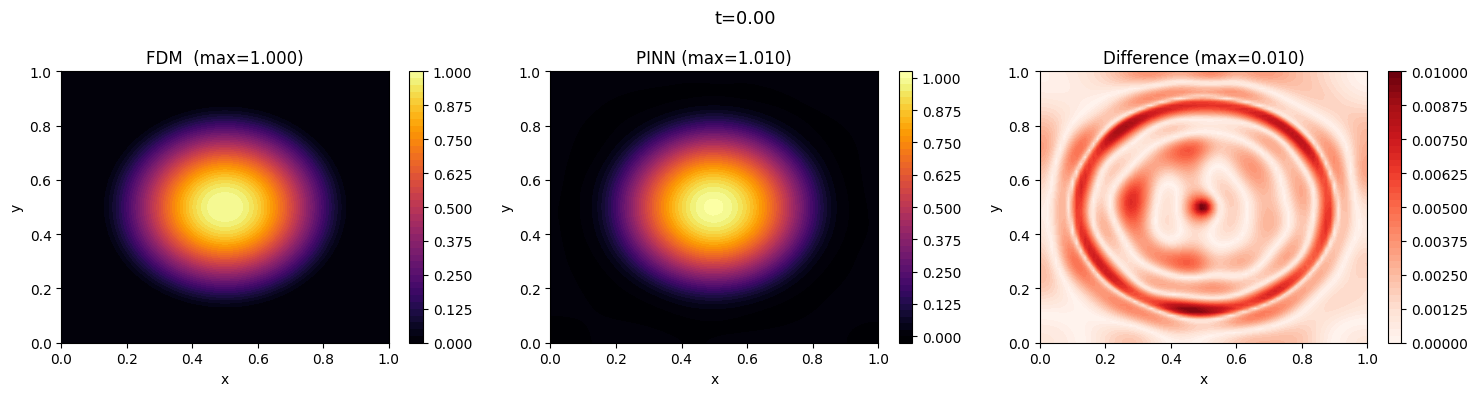

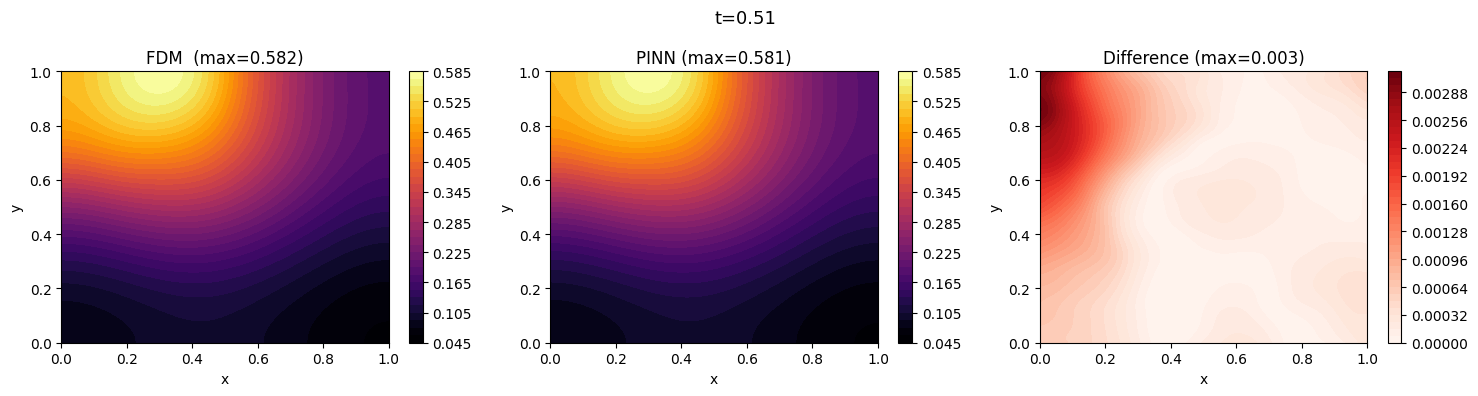

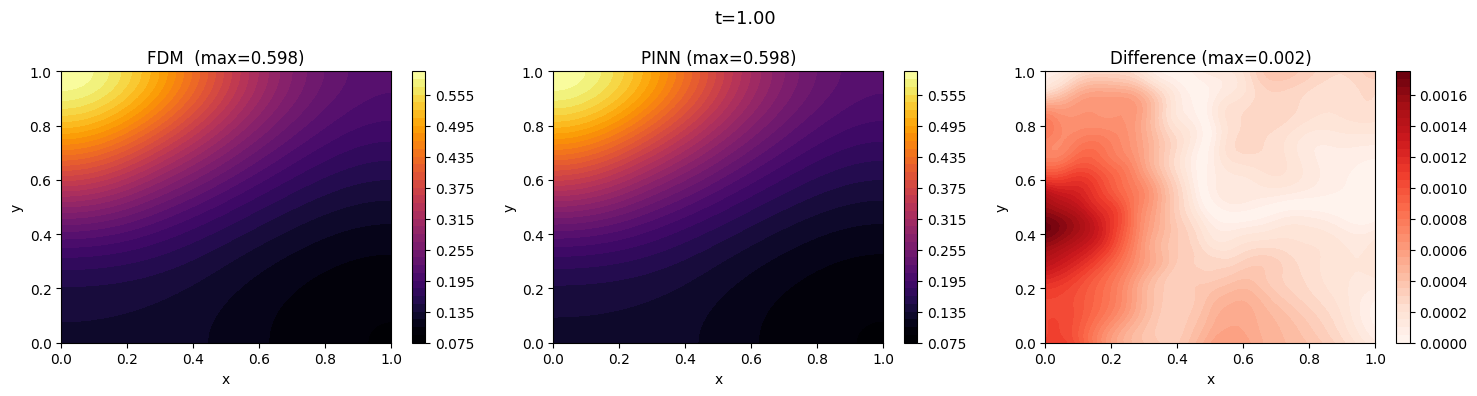

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import torch

N   = 80
n_frames = 40

x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
XX, YY = np.meshgrid(x, y)
dx = x[1] - x[0]

def ic_numpy(XX, YY):
    r = np.sqrt((XX - 0.5)**2 + (YY - 0.5)**2)
    c1, c2, c3 = 0.01, 0.4, 1.0
    h = (r - c1) / (c2 - c1)
    return c3 * (h - 1)**2 * (h + 1)**2 * (h < 1)

T = ic_numpy(XX, YY)

def fuel_ic_numpy(XX, YY):
    return 0.5 * (1.0 - np.tanh(20 * (XX - 0.5)))

S = fuel_ic_numpy(XX, YY)

dt = 0.00001
n_steps = int(1.0 / dt)
save_at = set(int(t / dt) for t in np.linspace(0, 1, n_frames))

fdm_list  = []
fdm_fuel_list = []
frame_idx = 0

t0 = time.perf_counter()
for step in range(n_steps + 1):
    if step in save_at and frame_idx < n_frames:
        fdm_list.append(T.copy())
        fdm_fuel_list.append(S.copy())
        frame_idx += 1
    P = np.pad(T, 1, mode='reflect')

    lap = (P[2:,1:-1] + P[:-2,1:-1] + P[1:-1,2:] + P[1:-1,:-2] - 4*T) / dx**2

    Tx  = (P[1:-1,2:] - P[1:-1,:-2]) / (2*dx)
    Ty  = (P[2:,1:-1] - P[:-2,1:-1]) / (2*dx)

    nonlin            = 3*T**2 * (Tx**2 + Ty**2) + T**3 * lap
    advection         = -C2 * (bx * Tx + by * Ty)
    cooling_newton    = C5 * (T0 - T)
    cooling_boltzmann = C6 * (T0**4 - T**4)
    reaction          = 1.0 / (1.0 + np.exp(-np.clip(K_IGN * (T - U_IGN), -60, 60)))
    source            = CR * S * reaction

    T = T + dt * (C3 * lap + C4 * nonlin + advection + cooling_newton + cooling_boltzmann + source)
    S = S + dt * (-CF * S * reaction)

    T = np.clip(T, -10, 10)

t_fdm = time.perf_counter() - t0
print(f"FDM time: {t_fdm:.1f} s")

save_times = np.linspace(0, 1, n_frames)
device = next(pinn_trained.parameters()).device
xf = torch.tensor(XX.reshape(-1,1), dtype=torch.float32).to(device)
yf = torch.tensor(YY.reshape(-1,1), dtype=torch.float32).to(device)

pinn_list = []
pinn_fuel_list = []
pinn_trained.eval()

if torch.cuda.is_available(): torch.cuda.synchronize()
t0 = time.perf_counter()
for tv in save_times:
    t_flat = torch.full_like(xf, tv)
    with torch.no_grad():
        out = pinn_trained(xf, yf, t_flat).cpu()
    pinn_list.append(out[:, 0:1].reshape(N, N).numpy())
    pinn_fuel_list.append(out[:, 1:2].reshape(N, N).numpy())

if torch.cuda.is_available(): torch.cuda.synchronize()
t_pred = time.perf_counter() - t0
n_eval = n_frames * N * N
print(f"Prediction time: {t_pred*1000:.1f} ms for {n_eval} points")

errors = []
for p, f_fdm in zip(pinn_list, fdm_list):
    norm_fdm = np.linalg.norm(f_fdm)
    if norm_fdm > 1e-10:
        errors.append(np.linalg.norm(p - f_fdm) / norm_fdm)
    else:
        errors.append(0.0)

errors_fuel = []
for p, s_fdm in zip(pinn_fuel_list, fdm_fuel_list):
    norm_fdm = np.linalg.norm(s_fdm)
    if norm_fdm > 1e-10:
        errors_fuel.append(np.linalg.norm(p - s_fdm) / norm_fdm)
    else:
        errors_fuel.append(0.0)

Ng = N * N
rmse      = [np.linalg.norm(p - f) / np.sqrt(Ng) for p, f in zip(pinn_list, fdm_list)]
rmse_fuel = [np.linalg.norm(p - s) / np.sqrt(Ng) for p, s in zip(pinn_fuel_list, fdm_fuel_list)]
print(f"RMSE (temperature): min={min(rmse):.2e}  max={max(rmse):.2e}  avg={np.mean(rmse):.2e}")
print(f"RMSE (fuel): min={min(rmse_fuel):.2e}  max={max(rmse_fuel):.2e}  avg={np.mean(rmse_fuel):.2e}")

print(f"Relative L2 error (temperature): min={min(errors):.4f}  max={max(errors):.4f}  avg={np.mean(errors):.4f}")
print(f"Relative L2 error (fuel): min={min(errors_fuel):.4f}  max={max(errors_fuel):.4f}  avg={np.mean(errors_fuel):.4f}")

for idx, label in [(0, "t=0.00"), (n_frames//2, "t=0.51"), (-1, "t=1.00")]:
    fdm_f  = fdm_list[idx]
    pinn_f = pinn_list[idx]
    diff   = np.abs(pinn_f - fdm_f)
    vmin   = min(fdm_f.min(), pinn_f.min())
    vmax   = max(fdm_f.max(), pinn_f.max())

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(label, fontsize=13)

    im0 = axes[0].contourf(XX, YY, fdm_f,  levels=40, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title(f"FDM  (max={fdm_f.max():.3f})")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].contourf(XX, YY, pinn_f, levels=40, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[1].set_title(f"PINN (max={pinn_f.max():.3f})")
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].contourf(XX, YY, diff,   levels=40, cmap="Reds")
    axes[2].set_title(f"Difference (max={diff.max():.3f})")
    plt.colorbar(im2, ax=axes[2])

    for ax in axes:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    plt.tight_layout()
    plt.show()

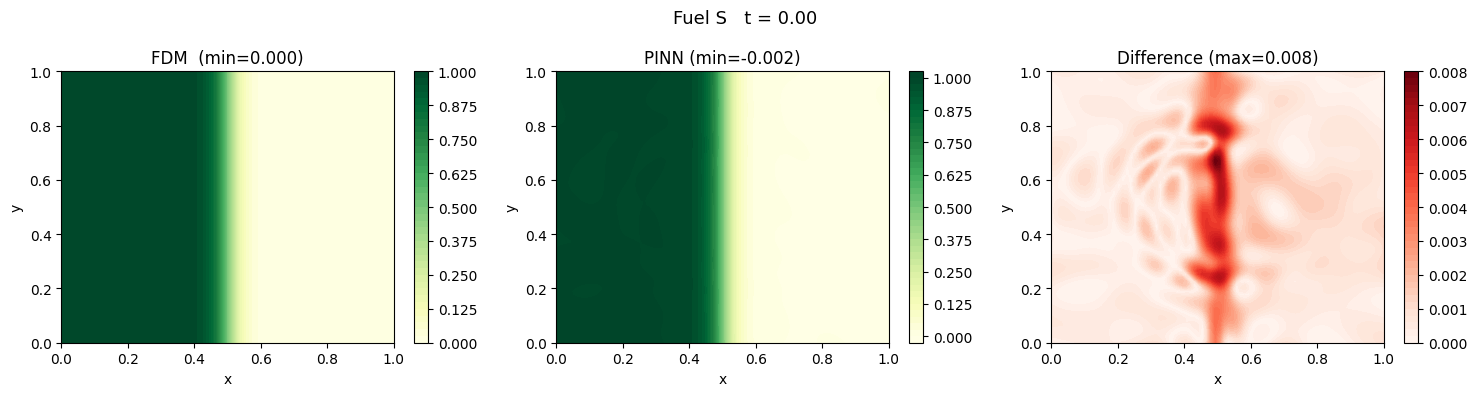

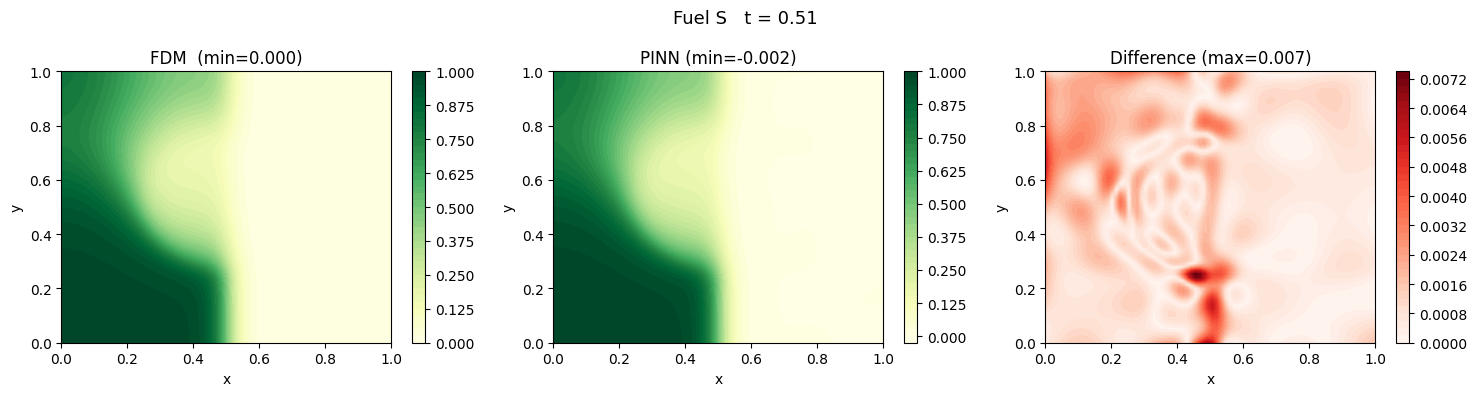

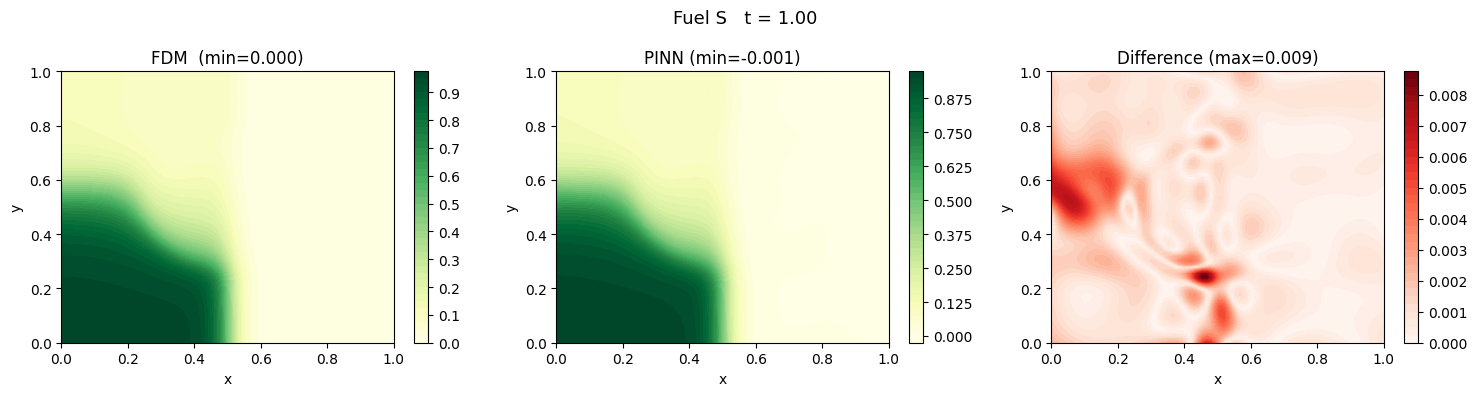

In [32]:
for idx in [0, n_frames // 2, n_frames - 1]:
    fdm_S  = fdm_fuel_list[idx]
    pinn_S = pinn_fuel_list[idx]
    diff   = np.abs(pinn_S - fdm_S)
    vmin   = min(fdm_S.min(), pinn_S.min())
    vmax   = max(fdm_S.max(), pinn_S.max())
    t_now  = save_times[idx]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Fuel S   t = {t_now:.2f}", fontsize=13)

    im0 = axes[0].contourf(XX, YY, fdm_S, levels=40, cmap="YlGn", vmin=vmin, vmax=vmax)
    axes[0].set_title(f"FDM  (min={fdm_S.min():.3f})")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].contourf(XX, YY, pinn_S, levels=40, cmap="YlGn", vmin=vmin, vmax=vmax)
    axes[1].set_title(f"PINN (min={pinn_S.min():.3f})")
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].contourf(XX, YY, diff, levels=40, cmap="Reds")
    axes[2].set_title(f"Difference (max={diff.max():.3f})")
    plt.colorbar(im2, ax=axes[2])

    for ax in axes:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    plt.tight_layout()
    plt.show()